https://www.kaggle.com/code/grantgonnerman/lung-cancer-classification

# Introduction

This project explores multiple Convolutional Neural Networks (CNNs) used to identify three types of lung cancer. More Americans die from lung cancer than any other type of cancer across both men and women. Getting an early diagnosis is critical to the full recovery of the patient. The goal for this project is to build a model to accurately detect types of lung cancer to assist doctors in their diagnosis. 

# Data Description

The dataset contains 15,000 images of three types of lungs. Each class contains 5,000 images. The three types of lungs included in this dataset are as follows: Adenocarcinoma, Squamous Cell Carcinoma, and Benign.

# Import libraries and Data

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf 

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
# Define paths and parameters
dataset_path = "/kaggle/input/lung-cancer-histopathological-images"
batch_size = 32
img_size = (224, 224)  # Resize images to a uniform size

# Load and split the data
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,  # 80% train, 20% validation
    subset="training",
    seed=123,  # Ensures reproducibility
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 15000 files belonging to 3 classes.
Using 12000 files for training.
Found 15000 files belonging to 3 classes.
Using 3000 files for validation.


# Exploratory Analysis

In [3]:
for images, labels in train_ds.take(1):
    print("Batch of images shape:", images.shape)
    print("Batch of labels shape:", labels.shape)

Batch of images shape: (32, 224, 224, 3)
Batch of labels shape: (32,)


In [4]:
print("Number of batches in train dataset:", len(train_ds))
print("Number of batches in validation dataset:", len(val_ds))

Number of batches in train dataset: 375
Number of batches in validation dataset: 94


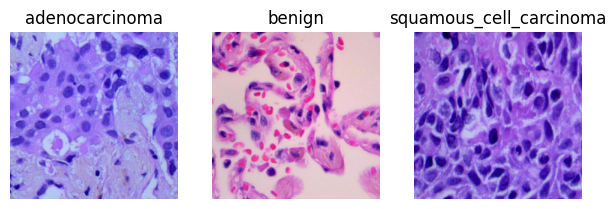

In [5]:
# Get class names
class_names = train_ds.class_names

# Create a figure for plotting
plt.figure(figsize=(10, 10))

# Iterate through each class
for i, class_name in enumerate(class_names):
    # Find a batch that contains images of the current class
    for images, labels in train_ds:
        # Check if this batch contains images of the current class
        for j in range(len(labels)):
            if class_names[labels[j]] == class_name:
                # Plot the first image of this class
                plt.subplot(4, 4, i + 1)  # Adjust grid size based on number of classes
                plt.imshow(images[j].numpy().astype("uint8"))
                plt.title(class_name)
                plt.axis("off")
                break
        else:
            continue
        break

# Show the plot with one image from each class
plt.show()

In [6]:
# function to plot training and valudation loss
def plot_acc_loss(hist):
    # Plot training & validation accuracy
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(hist.history['accuracy'], label='Train Accuracy')
    plt.plot(hist.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    
    # Plot training & validation loss
    plt.subplot(1, 2, 2)
    plt.plot(hist.history['loss'], label='Train Loss')
    plt.plot(hist.history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    
    plt.show()

# Model 1

In [7]:
md1 = tf.keras.models.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(224, 224, 3)),
    tf.keras.layers.Conv2D(16,kernel_size=(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Conv2D(32,kernel_size=(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Conv2D(64,kernel_size=(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dense(3,activation='softmax')
])
md1.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

history = md1.fit(train_ds, validation_data = val_ds, epochs=10)

Epoch 1/10


/opt/conda/lib/python3.10/site-packages/keras/src/layers/preprocessing/tf_data_layer.py:18: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


375/375 ━━━━━━━━━━━━━━━━━━━━ 356s 945ms/step - accuracy: 0.7759 - loss: 0.5028 - val_accuracy: 0.8647 - val_loss: 0.3213
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 348s 928ms/step - accuracy: 0.9065 - loss: 0.2340 - val_accuracy: 0.9367 - val_loss: 0.1727
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 349s 931ms/step - accuracy: 0.9358 - loss: 0.1593 - val_accuracy: 0.9347 - val_loss: 0.1777
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 360s 960ms/step - accuracy: 0.9574 - loss: 0.1178 - val_accuracy: 0.9153 - val_loss: 0.2336
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 342s 911ms/step - accuracy: 0.9703 - loss: 0.0773 - val_accuracy: 0.9347 - val_loss: 0.1643
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 384s 918ms/step - accuracy: 0.9782 - loss: 0.0620 - val_accuracy: 0.9553 - val_loss: 0.1390
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 343s 915ms/step - accuracy: 0.9880 - loss: 0.0355 - val_accuracy: 0.9387 - val_loss: 0.2004
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 347s 925ms/step - accuracy: 0.9921 - loss: 0.02

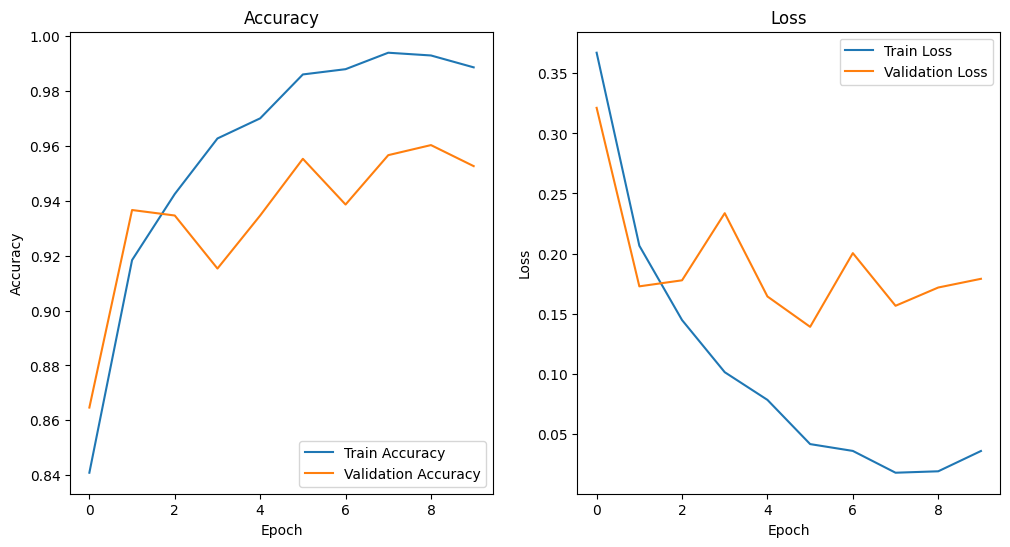

In [8]:
plot_acc_loss(history)

In [9]:
val_loss, val_accuracy = md1.evaluate(val_ds, verbose=2)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

94/94 - 28s - 294ms/step - accuracy: 0.9527 - loss: 0.1790
Validation Loss: 0.1790
Validation Accuracy: 0.9527


# Model 2

In [10]:
md2 = tf.keras.models.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(224, 224, 3)),
    tf.keras.layers.Conv2D(16,kernel_size=(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Conv2D(32,kernel_size=(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Conv2D(64,kernel_size=(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(3,activation='softmax')
])
md2.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

history = md2.fit(train_ds, validation_data = val_ds, epochs=10)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 356s 945ms/step - accuracy: 0.7435 - loss: 0.5263 - val_accuracy: 0.8963 - val_loss: 0.2462
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 363s 967ms/step - accuracy: 0.8828 - loss: 0.2818 - val_accuracy: 0.9147 - val_loss: 0.2050
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 349s 928ms/step - accuracy: 0.9148 - loss: 0.2071 - val_accuracy: 0.9257 - val_loss: 0.1866
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 345s 920ms/step - accuracy: 0.9301 - loss: 0.1669 - val_accuracy: 0.9420 - val_loss: 0.1539
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 348s 929ms/step - accuracy: 0.9474 - loss: 0.1360 - val_accuracy: 0.9557 - val_loss: 0.1354
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 393s 1s/step - accuracy: 0.9517 - loss: 0.1238 - val_accuracy: 0.9590 - val_loss: 0.1206
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 385s 1s/step - accuracy: 0.9634 - loss: 0.0982 - val_accuracy: 0.9630 - val_loss: 0.1127
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 442s 1s/step - accuracy: 0.9764 - loss: 0.

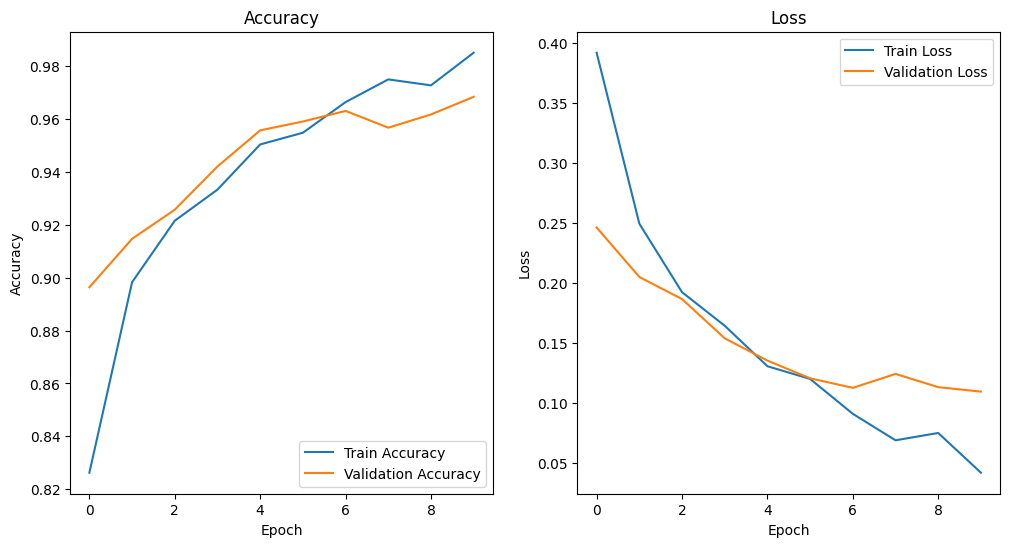

In [11]:
plot_acc_loss(history)

In [12]:
val_loss, val_accuracy = md2.evaluate(val_ds, verbose=2)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

94/94 - 29s - 312ms/step - accuracy: 0.9683 - loss: 0.1095
Validation Loss: 0.1095
Validation Accuracy: 0.9683


# Model 3

In [13]:
md3 = tf.keras.models.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(224, 224, 3)),
    tf.keras.layers.Conv2D(16,kernel_size=(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Conv2D(32,kernel_size=(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Conv2D(64,kernel_size=(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(3,activation='softmax')
])
md3.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

history = md3.fit(train_ds, validation_data = val_ds, epochs=10)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 394s 1s/step - accuracy: 0.7535 - loss: 0.5236 - val_accuracy: 0.8697 - val_loss: 0.3152
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 443s 1s/step - accuracy: 0.8868 - loss: 0.2891 - val_accuracy: 0.8587 - val_loss: 0.3078
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 442s 1s/step - accuracy: 0.9005 - loss: 0.2468 - val_accuracy: 0.9180 - val_loss: 0.2019
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 394s 1s/step - accuracy: 0.9283 - loss: 0.1825 - val_accuracy: 0.9370 - val_loss: 0.1554
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 441s 1s/step - accuracy: 0.9351 - loss: 0.1633 - val_accuracy: 0.9433 - val_loss: 0.1471
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 439s 1s/step - accuracy: 0.9451 - loss: 0.1454 - val_accuracy: 0.9527 - val_loss: 0.1258
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 382s 1s/step - accuracy: 0.9528 - loss: 0.1247 - val_accuracy: 0.9490 - val_loss: 0.1316
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 349s 931ms/step - accuracy: 0.9531 - loss: 0.1332 - val_a

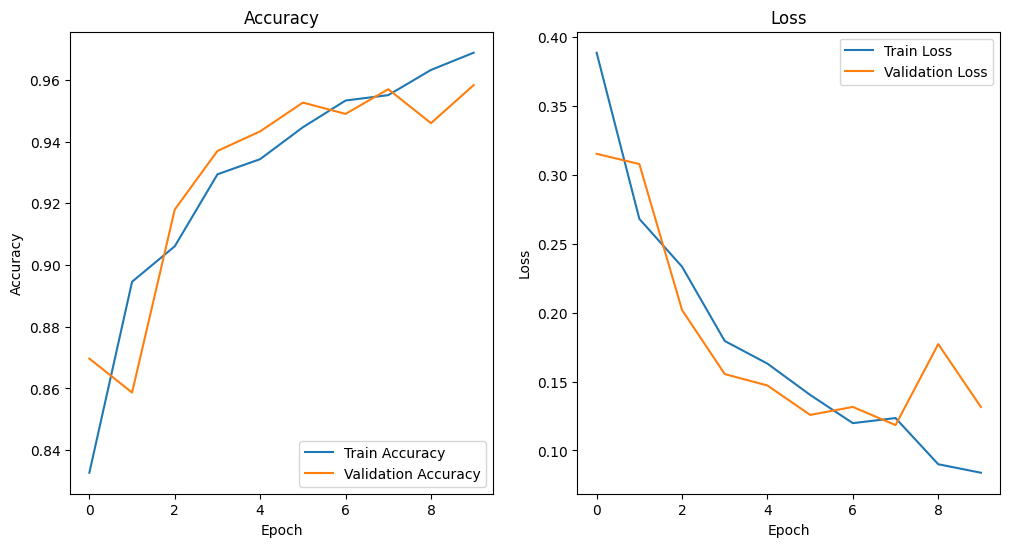

In [14]:
plot_acc_loss(history)

In [15]:
val_loss, val_accuracy = md3.evaluate(val_ds, verbose=2)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

94/94 - 28s - 297ms/step - accuracy: 0.9583 - loss: 0.1315
Validation Loss: 0.1315
Validation Accuracy: 0.9583


# Model 4

In [16]:
md4 = tf.keras.models.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(224, 224, 3)),
    tf.keras.layers.Conv2D(16,kernel_size=(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Conv2D(32,kernel_size=(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Conv2D(64,kernel_size=(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(3,activation='softmax')
])
md4.compile(optimizer='RMSprop',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

history = md4.fit(train_ds, validation_data = val_ds, epochs=10)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 366s 973ms/step - accuracy: 0.6353 - loss: 0.7148 - val_accuracy: 0.8433 - val_loss: 0.3586
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 357s 950ms/step - accuracy: 0.8473 - loss: 0.3563 - val_accuracy: 0.8543 - val_loss: 0.2998
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 379s 942ms/step - accuracy: 0.8996 - loss: 0.2486 - val_accuracy: 0.9053 - val_loss: 0.2346
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 394s 974ms/step - accuracy: 0.9173 - loss: 0.1994 - val_accuracy: 0.9403 - val_loss: 0.1548
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 374s 997ms/step - accuracy: 0.9373 - loss: 0.1563 - val_accuracy: 0.9430 - val_loss: 0.1425
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 355s 947ms/step - accuracy: 0.9481 - loss: 0.1330 - val_accuracy: 0.9377 - val_loss: 0.1660
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 398s 991ms/step - accuracy: 0.9578 - loss: 0.1090 - val_accuracy: 0.9603 - val_loss: 0.1079
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 376s 1s/step - accuracy: 0.9678 - lo

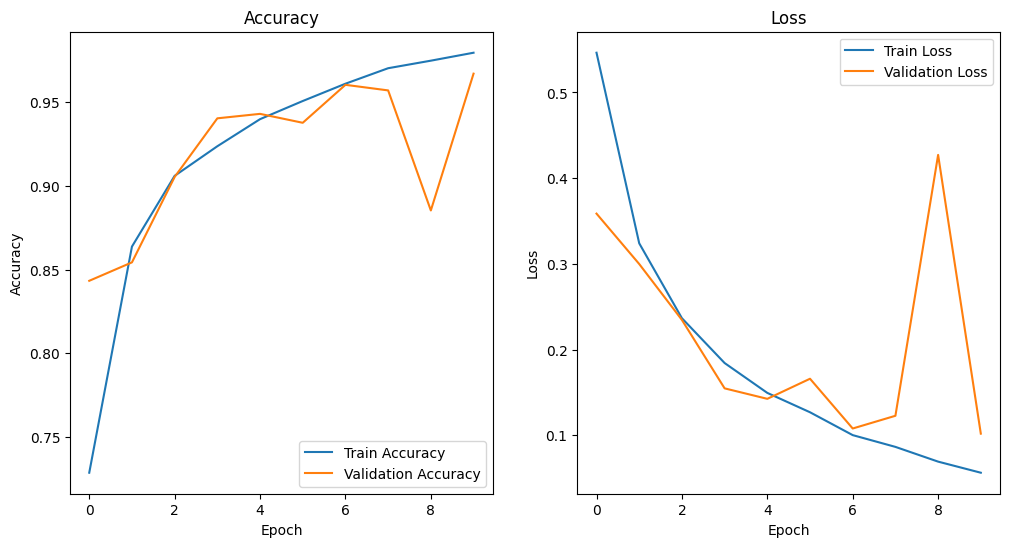

In [17]:
plot_acc_loss(history)

In [18]:
val_loss, val_accuracy = md4.evaluate(val_ds, verbose=2)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

94/94 - 28s - 298ms/step - accuracy: 0.9670 - loss: 0.1019
Validation Loss: 0.1019
Validation Accuracy: 0.9670


# Model 5

In [19]:
md5 = tf.keras.models.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(224, 224, 3)),
    tf.keras.layers.Conv2D(16,kernel_size=(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Conv2D(32,kernel_size=(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Conv2D(64,kernel_size=(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(3,activation='softmax')
])
md5.compile(optimizer='RMSprop',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

history = md5.fit(train_ds, validation_data = val_ds, epochs=10)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 361s 960ms/step - accuracy: 0.6782 - loss: 0.6628 - val_accuracy: 0.8867 - val_loss: 0.2681
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 361s 961ms/step - accuracy: 0.8707 - loss: 0.3256 - val_accuracy: 0.9333 - val_loss: 0.1806
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 368s 980ms/step - accuracy: 0.9106 - loss: 0.2451 - val_accuracy: 0.9270 - val_loss: 0.1700
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 370s 950ms/step - accuracy: 0.9227 - loss: 0.2002 - val_accuracy: 0.9163 - val_loss: 0.2170
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 353s 942ms/step - accuracy: 0.9401 - loss: 0.1599 - val_accuracy: 0.9470 - val_loss: 0.1391
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 382s 942ms/step - accuracy: 0.9514 - loss: 0.1314 - val_accuracy: 0.9350 - val_loss: 0.1633
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 383s 945ms/step - accuracy: 0.9554 - loss: 0.1185 - val_accuracy: 0.9693 - val_loss: 0.0796
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 366s 977ms/step - accuracy: 0.9647 -

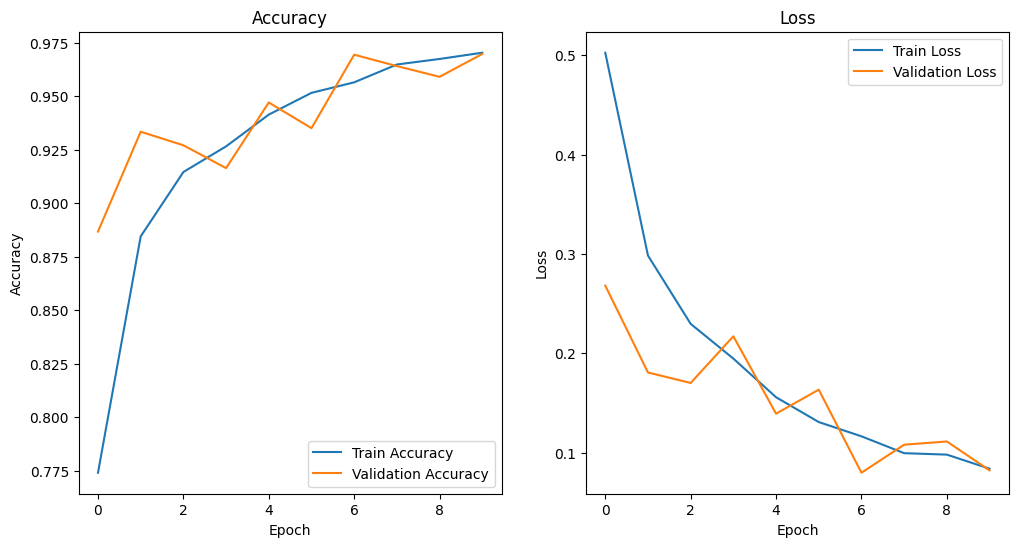

In [20]:
plot_acc_loss(history)

In [21]:
val_loss, val_accuracy = md5.evaluate(val_ds, verbose=2)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

94/94 - 27s - 289ms/step - accuracy: 0.9697 - loss: 0.0820
Validation Loss: 0.0820
Validation Accuracy: 0.9697
